In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from DoE_module import t as sp_t
import seaborn as sns
sns.set_theme()

def show_matrix(m: pd.DataFrame, cmap="coolwarm", cbar=False, annot=True, **kwargs):
    axim = sns.heatmap(m.rename(columns=dict(Intercep="I")), cmap=cmap, cbar=cbar, annot=annot, **kwargs)
    axim.xaxis.set_ticks_position("top")
    axim.yaxis.set_ticks_position("right")

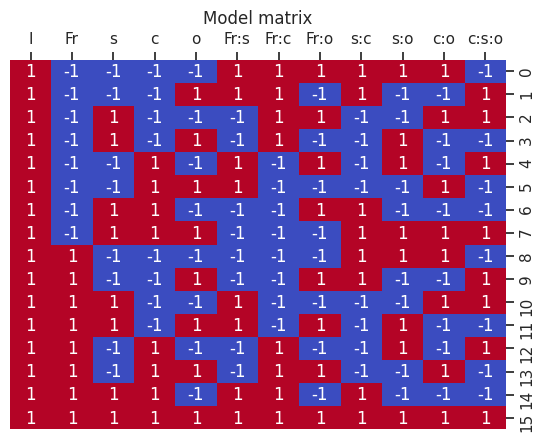

In [2]:
M = pd.read_csv("matrix_model.csv")
show_matrix(M)
plt.title("Model matrix")
plt.show()

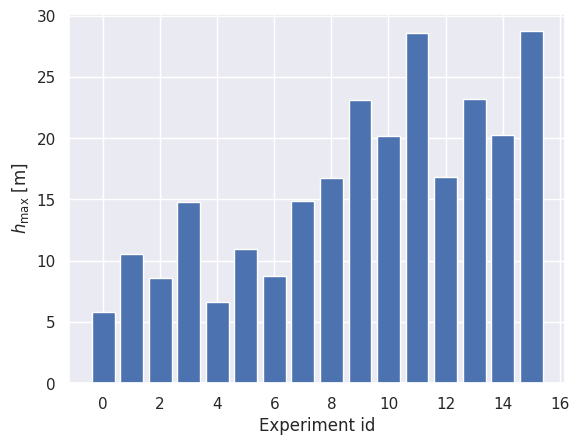

In [3]:
R = np.loadtxt("hmax.txt")
plt.bar(x=np.arange(R.size), height=R)
plt.xlabel("Experiment id")
plt.ylabel(r"$h_\mathrm{max}$ [m]")
plt.show()

In [8]:
def half_effects(M, R):
    Half_effects = np.linalg.solve(M.T @ M, M.T @ R)
    Rel_effects = Half_effects / Half_effects[0]

    beta = 0.95
    alpha = 1-beta
    dof = M.shape[0] - M.shape[1]
    t_student = sp_t.ppf(beta + alpha/2, dof)

    residue = R - M @ Half_effects
    var_exp = residue.T @ residue /(dof)
    D3 = np.linalg.inv(M.T @ M)
    CI = t_student * np.sqrt(np.diag(D3) * var_exp)

    return pd.DataFrame(
        np.vstack((Half_effects.T, CI.T, Rel_effects.T)),
        index=["Half-effects", f"{beta:.0%} CI", "Relative"],
        columns=M.columns
    ).drop(columns=["I"])



In [9]:
effect_df = half_effects(M, R)

display(
  effect_df
  .T
  .round(3)
  .style.background_gradient(cmap="coolwarm", axis="columns")
  .format(precision=3)
)

,Half-effects,95% CI,Relative
Fr,6.047,0.145,0.374
s,1.933,0.145,0.120
c,0.105,0.145,0.007
o,3.180,0.145,0.197
Fr:s,0.304,0.145,0.019
Fr:c,-0.071,0.145,-0.004
Fr:o,0.522,0.145,0.032
s:c,-0.054,0.145,-0.003
s:o,0.469,0.145,0.029
c:o,-0.024,0.145,-0.001


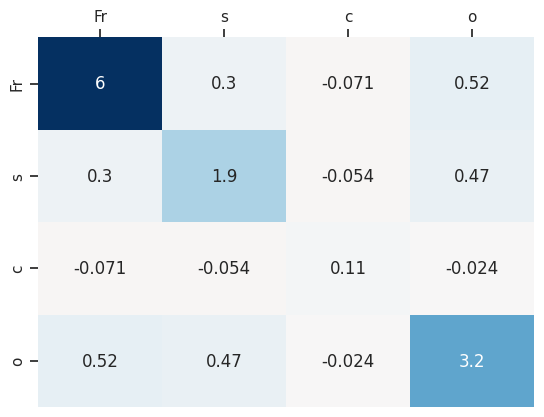

In [5]:
main_factors = "Fr s c o".split()
effect_matrix = np.zeros((len(main_factors), len(main_factors)), dtype=np.float16)
for i, f1 in enumerate(main_factors):
    for j, f2 in enumerate(main_factors[i:], start=i):
        if f1 == f2:
            f = f1
        else:
            f = f"{f1}:{f2}"
        effect_matrix[i, j] = effect_df[f].iloc[0]
        effect_matrix[j, i] = effect_df[f].iloc[0]

effect_matrix = pd.DataFrame(effect_matrix, columns=main_factors)
vmax = np.abs(effect_matrix).max(axis=None)

show_matrix(effect_matrix, vmin=-vmax, vmax=vmax, cmap="RdBu")
plt.yticks(np.arange(len(main_factors))+1/2, main_factors)
plt.gca().yaxis.tick_left()
plt.show()